In [1]:
import cv2
import os
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def ekstraksi_fitur_ikan(img_path):
    # baca gambar
    image = cv2.imread(img_path)
    if image is None:
        return None

    image = cv2.resize(image, (256, 256))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    main_contour = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(main_contour)
    perimeter = cv2.arcLength(main_contour, True)

    x, y, w, h = cv2.boundingRect(main_contour)

    aspect_ratio = float(w) / h if h != 0 else 0

    circularity = (
        (4 * np.pi * area) / (perimeter ** 2)
        if perimeter != 0 else 0
    )

    hull = cv2.convexHull(main_contour)
    hull_area = cv2.contourArea(hull)

    solidity = (
        float(area) / hull_area
        if hull_area != 0 else 0
    )

    mask = np.zeros(gray.shape, dtype="uint8")

    cv2.drawContours(
        mask,
        [main_contour],
        -1,
        255,
        -1
    )

    hsv_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HSV
    )

    h_channel, s_channel, v_channel = cv2.split(hsv_image)

    mean_h = cv2.mean(
        h_channel,
        mask=mask
    )[0]

    mean_s = cv2.mean(
        s_channel,
        mask=mask
    )[0]

    mean_v = cv2.mean(
        v_channel,
        mask=mask
    )[0]

    gray_masked = cv2.bitwise_and(
        gray,
        gray,
        mask=mask
    )

    glcm = graycomatrix(
        gray_masked,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(
        glcm,
        'contrast'
    )[0, 0]

    correlation = graycoprops(
        glcm,
        'correlation'
    )[0, 0]

    energy = graycoprops(
        glcm,
        'energy'
    )[0, 0]

    homogeneity = graycoprops(
        glcm,
        'homogeneity'
    )[0, 0]

    return {
        "Bentuk_Aspect_Ratio": aspect_ratio,
        "Bentuk_Solidity": solidity,
        "Bentuk_Circularity": circularity,
        "Warna_Mean_Hue": mean_h,
        "Warna_Mean_Saturation": mean_s,
        "Warna_Mean_Value": mean_v,
        "Tekstur_Contrast": contrast,
        "Tekstur_Correlation": correlation,
        "Tekstur_Energy": energy,
        "Tekstur_Homogeneity": homogeneity
    }

In [3]:
# =========================================================
# CELL 3 - EKSTRAKSI FITUR SELURUH DATASET
# =========================================================

import os
import pandas as pd

# Path dataset
dataset_path = r"A Large Scale Fish Dataset"

data_fitur = []

print("=" * 60)
print("MEMULAI EKSTRAKSI FITUR IKAN")
print("=" * 60)

# Membaca seluruh subfolder spesies
for root, dirs, files in os.walk(dataset_path):

    spesies = os.path.basename(root)

    for filename in files:

        if filename.lower().endswith((".jpg", ".jpeg", ".png")):

            img_path = os.path.join(root, filename)

            fitur = ekstraksi_fitur_ikan(img_path)

            if fitur is not None:

                fitur["Nama_File"] = filename
                fitur["Spesies"] = spesies

                data_fitur.append(fitur)

# =========================================================
# MEMBUAT DATAFRAME
# =========================================================

df_master = pd.DataFrame(data_fitur)

# Pindahkan Nama_File dan Spesies ke depan
kolom_utama = ["Nama_File", "Spesies"]
kolom_lain = [col for col in df_master.columns if col not in kolom_utama]

df_master = df_master[kolom_utama + kolom_lain]

print(f"\nTotal data berhasil diekstrak : {len(df_master)}")
print(f"Jumlah kolom fitur           : {len(df_master.columns)}")

# =========================================================
# MEMISAHKAN FITUR BERDASARKAN KATEGORI
# =========================================================

kolom_identitas = [
    "Nama_File",
    "Spesies"
]

kolom_bentuk = kolom_identitas + [
    col for col in df_master.columns
    if col.startswith("Bentuk")
]

kolom_warna = kolom_identitas + [
    col for col in df_master.columns
    if col.startswith("Warna")
]

kolom_tekstur = kolom_identitas + [
    col for col in df_master.columns
    if col.startswith("Tekstur")
]

df_bentuk = df_master[kolom_bentuk]
df_warna = df_master[kolom_warna]
df_tekstur = df_master[kolom_tekstur]

# =========================================================
# SIMPAN KE EXCEL MULTI-SHEET
# =========================================================

nama_excel = "Dataset_Fitur_Ikan.xlsx"

with pd.ExcelWriter(
    nama_excel,
    engine="openpyxl"
) as writer:

    df_bentuk.to_excel(
        writer,
        sheet_name="Bentuk",
        index=False
    )

    df_warna.to_excel(
        writer,
        sheet_name="Warna",
        index=False
    )

    df_tekstur.to_excel(
        writer,
        sheet_name="Tekstur",
        index=False
    )

    df_master.to_excel(
        writer,
        sheet_name="Semua_Fitur",
        index=False
    )

print("\n" + "=" * 60)
print("EKSTRAKSI SELESAI")
print("=" * 60)
print(f"File Excel berhasil disimpan : {nama_excel}")

# Menampilkan 5 data pertama
display(df_master.head())

MEMULAI EKSTRAKSI FITUR IKAN

Total data berhasil diekstrak : 9435
Jumlah kolom fitur           : 12

EKSTRAKSI SELESAI
File Excel berhasil disimpan : Dataset_Fitur_Ikan.xlsx


,Nama_File,Spesies,Bentuk_Aspect_Ratio,Bentuk_Solidity,Bentuk_Circularity,Warna_Mean_Hue,Warna_Mean_Saturation,Warna_Mean_Value,Tekstur_Contrast,Tekstur_Correlation,Tekstur_Energy,Tekstur_Homogeneity
0,00001.png,Black Sea Sprat,1.088889,0.962449,0.524294,3.549598,4.990170,1.926720,4.781342,0.467085,0.996354,0.996500
1,00002.png,Black Sea Sprat,1.088889,0.962449,0.524294,3.549598,4.990170,1.926720,4.781342,0.467085,0.996354,0.996500
2,00003.png,Black Sea Sprat,0.468354,0.962357,0.416329,3.051128,4.350376,1.575272,6.465043,0.332781,0.995512,0.995705
3,00004.png,Black Sea Sprat,0.468354,0.962357,0.416329,3.051128,4.350376,1.575272,6.465043,0.332781,0.995512,0.995705
4,00005.png,Black Sea Sprat,0.611940,0.957768,0.465485,3.124888,4.701956,1.718823,6.117601,0.368705,0.995665,0.995857


In [4]:
# =========================================================
# CELL 4 - FILTER DATASET MENJADI 2 KELAS
# =========================================================

import pandas as pd

# Membaca sheet Semua_Fitur
file_excel = "Dataset_Fitur_Ikan.xlsx"

df = pd.read_excel(
    file_excel,
    sheet_name="Semua_Fitur"
)

print("=" * 60)
print("DATASET AWAL")
print("=" * 60)

print(f"Jumlah data : {len(df)}")
print(f"Jumlah spesies : {df['Spesies'].nunique()}")

# =========================================================
# FILTER 2 KELAS
# =========================================================

kelas_target = [
    "Sea Bass",
    "Red Mullet"
]

df_2kelas = df[
    df["Spesies"].isin(kelas_target)
].copy()

print("\n" + "=" * 60)
print("DATASET SETELAH FILTER")
print("=" * 60)

print(f"Jumlah data : {len(df_2kelas)}")

print("\nDistribusi Kelas:")
print(df_2kelas["Spesies"].value_counts())

# =========================================================
# SIMPAN HASIL FILTER
# =========================================================

nama_file_filter = "Dataset_2_Kelas_Ikan.xlsx"

df_2kelas.to_excel(
    nama_file_filter,
    index=False
)

print("\nDataset berhasil disimpan:")
print(nama_file_filter)

# =========================================================
# PREVIEW DATA
# =========================================================

display(df_2kelas.head())

DATASET AWAL
Jumlah data : 9435
Jumlah spesies : 12

DATASET SETELAH FILTER
Jumlah data : 2100

Distribusi Kelas:
Spesies
Red Mullet    1050
Sea Bass      1050
Name: count, dtype: int64

Dataset berhasil disimpan:
Dataset_2_Kelas_Ikan.xlsx


,Nama_File,Spesies,Bentuk_Aspect_Ratio,Bentuk_Solidity,Bentuk_Circularity,Warna_Mean_Hue,Warna_Mean_Saturation,Warna_Mean_Value,Tekstur_Contrast,Tekstur_Correlation,Tekstur_Energy,Tekstur_Homogeneity
3005,00001.png,Red Mullet,1.000000,0.302087,0.057893,65.366014,95.091142,38.382929,43.247472,0.863975,0.900074,0.927861
3006,00002.png,Red Mullet,1.000000,0.302087,0.057893,65.366014,95.091142,38.382929,43.247472,0.863975,0.900074,0.927861
3007,00003.png,Red Mullet,1.815603,0.415129,0.060547,90.210720,117.932548,77.253530,97.696967,0.913026,0.831276,0.877153
3008,00004.png,Red Mullet,1.815603,0.415129,0.060547,90.210720,117.932548,77.253530,97.696967,0.913026,0.831276,0.877153
3009,00005.png,Red Mullet,1.000000,0.318943,0.069967,65.443868,95.160032,37.260528,40.910570,0.858805,0.903428,0.928749


In [5]:
# =========================================================
# CELL 5 - SUPPORT VECTOR MACHINE (SVM)
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

file_excel = "Dataset_2_Kelas_Ikan.xlsx"

df = pd.read_excel(file_excel)

X = df.drop(columns=[
    "Nama_File",
    "Spesies"
])

y = df["Spesies"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("MODEL 1 : SUPPORT VECTOR MACHINE")
print("=" * 60)

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm_model.predict(
    X_test_scaled
)

akurasi_svm = accuracy_score(
    y_test,
    svm_pred
) * 100

print(f"\nAkurasi SVM : {akurasi_svm:.2f}%\n")

print(
    classification_report(
        y_test,
        svm_pred
    )
)

MODEL 1 : SUPPORT VECTOR MACHINE

Akurasi SVM : 92.14%

              precision    recall  f1-score   support

  Red Mullet       0.93      0.91      0.92       210
    Sea Bass       0.91      0.93      0.92       210

    accuracy                           0.92       420
   macro avg       0.92      0.92      0.92       420
weighted avg       0.92      0.92      0.92       420



In [6]:
# =========================================================
# CELL 6 - RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("MODEL 2 : RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_pred = rf_model.predict(
    X_test_scaled
)

akurasi_rf = accuracy_score(
    y_test,
    rf_pred
) * 100

print(f"\nAkurasi Random Forest : {akurasi_rf:.2f}%\n")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

MODEL 2 : RANDOM FOREST

Akurasi Random Forest : 99.05%

              precision    recall  f1-score   support

  Red Mullet       1.00      0.98      0.99       210
    Sea Bass       0.98      1.00      0.99       210

    accuracy                           0.99       420
   macro avg       0.99      0.99      0.99       420
weighted avg       0.99      0.99      0.99       420



,Fitur,Importance
3,Warna_Mean_Hue,0.209807
4,Warna_Mean_Saturation,0.140025
9,Tekstur_Homogeneity,0.118169
6,Tekstur_Contrast,0.108770
8,Tekstur_Energy,0.093600
5,Warna_Mean_Value,0.080711
0,Bentuk_Aspect_Ratio,0.074756
7,Tekstur_Correlation,0.066667
1,Bentuk_Solidity,0.061781
2,Bentuk_Circularity,0.045715


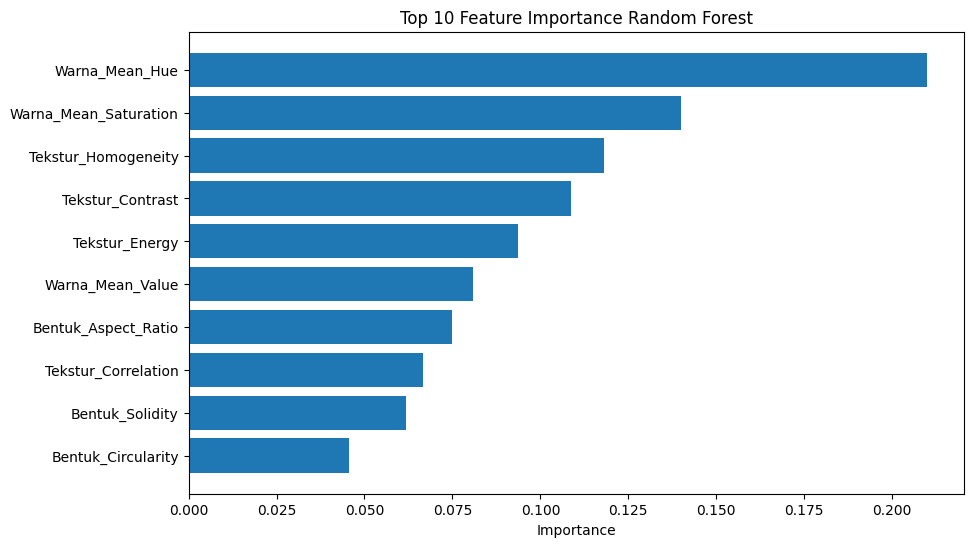

In [7]:
# =========================================================
# CELL 7 - FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({
    "Fitur": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    feature_importance.head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Fitur"].head(10),
    feature_importance["Importance"].head(10)
)

plt.title(
    "Top 10 Feature Importance Random Forest"
)

plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [8]:
# =========================================================
# CELL 8 - K NEAREST NEIGHBOR
# =========================================================

from sklearn.neighbors import KNeighborsClassifier

print("=" * 60)
print("MODEL 3 : KNN")
print("=" * 60)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn_model.predict(
    X_test_scaled
)

akurasi_knn = accuracy_score(
    y_test,
    knn_pred
) * 100

print(f"\nAkurasi KNN : {akurasi_knn:.2f}%\n")

print(
    classification_report(
        y_test,
        knn_pred
    )
)

MODEL 3 : KNN

Akurasi KNN : 94.76%

              precision    recall  f1-score   support

  Red Mullet       0.97      0.93      0.95       210
    Sea Bass       0.93      0.97      0.95       210

    accuracy                           0.95       420
   macro avg       0.95      0.95      0.95       420
weighted avg       0.95      0.95      0.95       420



In [9]:
# =========================================================
# CELL 9 - GAUSSIAN NAIVE BAYES
# =========================================================

from sklearn.naive_bayes import GaussianNB

print("=" * 60)
print("MODEL 4 : GAUSSIAN NAIVE BAYES")
print("=" * 60)

nb_model = GaussianNB()

nb_model.fit(
    X_train_scaled,
    y_train
)

nb_pred = nb_model.predict(
    X_test_scaled
)

akurasi_nb = accuracy_score(
    y_test,
    nb_pred
) * 100

print(f"\nAkurasi Naive Bayes : {akurasi_nb:.2f}%\n")

print(
    classification_report(
        y_test,
        nb_pred
    )
)

MODEL 4 : GAUSSIAN NAIVE BAYES

Akurasi Naive Bayes : 59.05%

              precision    recall  f1-score   support

  Red Mullet       0.70      0.31      0.43       210
    Sea Bass       0.56      0.87      0.68       210

    accuracy                           0.59       420
   macro avg       0.63      0.59      0.56       420
weighted avg       0.63      0.59      0.56       420



PERBANDINGAN AKURASI MODEL


,Model,Accuracy (%)
1,Random Forest,99.047619
2,KNN,94.761905
0,SVM,92.142857
3,Naive Bayes,59.047619



Model terbaik adalah Random Forest dengan akurasi 99.05%


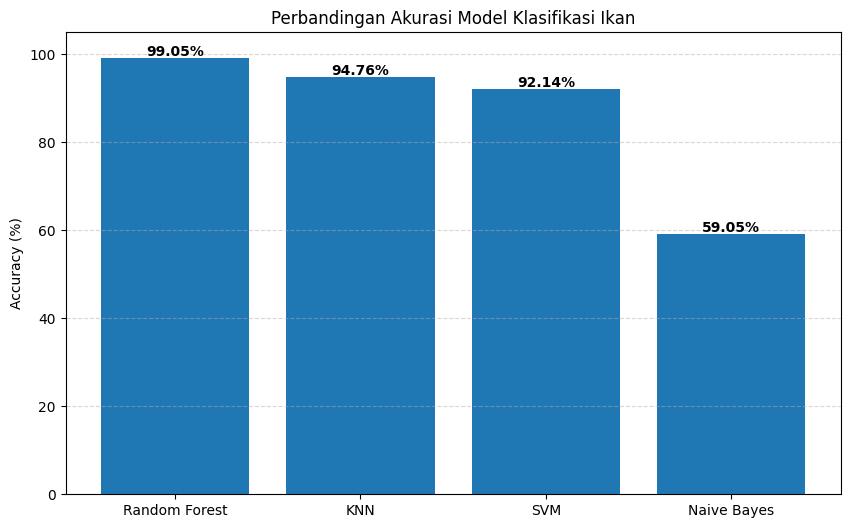

In [10]:
# =========================================================
# CELL 10 - PERBANDINGAN MODEL
# =========================================================

hasil_model = pd.DataFrame({
    "Model": [
        "SVM",
        "Random Forest",
        "KNN",
        "Naive Bayes"
    ],
    "Accuracy (%)": [
        akurasi_svm,
        akurasi_rf,
        akurasi_knn,
        akurasi_nb
    ]
})

hasil_model = hasil_model.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print("=" * 60)
print("PERBANDINGAN AKURASI MODEL")
print("=" * 60)

display(hasil_model)

print(
    f"\nModel terbaik adalah "
    f"{hasil_model.iloc[0]['Model']} "
    f"dengan akurasi "
    f"{hasil_model.iloc[0]['Accuracy (%)']:.2f}%"
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    hasil_model["Model"],
    hasil_model["Accuracy (%)"]
)

for bar in bars:

    nilai = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        nilai + 0.5,
        f"{nilai:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Perbandingan Akurasi Model Klasifikasi Ikan"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(0, 105)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()